In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_excel('02-Churn-Dataset.xlsx')

In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'numAdminTickets',
       'numTechTickets', 'Churn'],
      dtype='str')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,0,0,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,Yes


In [5]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Checking for null values

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
numAdminTickets     0
numTechTickets      0
Churn               0
dtype: int64

Data preprocessing

In [8]:
df['gender'] = df['gender'].replace({'Female': 0, 'Male': 1})
df['Partner'] = df['Partner'].replace({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].replace({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].replace({'Yes': 1, 'No': 0})

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,0,0,No
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,Yes
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,No
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,Yes


In [10]:
df['MultipleLines'].unique()

<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

In [11]:
df['MultipleLines'] = df['MultipleLines'].replace({'Yes': 1, 'No': 0, 'No phone service': 2})

In [12]:
df['StreamingTV'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [13]:
df['InternetService'] = df['InternetService'].replace({'DSL': 1, 'Fiber optic': 2, 'No': 0})
df['OnlineSecurity'] = df['OnlineSecurity'].replace({'Yes': 1, 'No': 0, 'No internet service': 2})
df['StreamingTV'] = df['StreamingTV'].replace({'Yes': 1, 'No': 0, 'No internet service': 2})

In [14]:
df['Contract'].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [15]:
df['Contract'] = df['Contract'].replace({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

In [16]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'numAdminTickets',
       'numTechTickets', 'Churn'],
      dtype='str')

In [17]:
pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.max_colwidth', None)  # don't truncate cell content
pd.set_option('display.width', None)         # don't wrap based on terminal width

In [18]:
df['OnlineBackup'] = df['OnlineBackup'].replace({'Yes': 1, 'No': 0, 'No internet service': 2})
df['DeviceProtection'] = df['DeviceProtection'].replace({'Yes': 1, 'No': 0, 'No internet service': 2})
df['TechSupport'] = df['TechSupport'].replace({'Yes': 1, 'No': 0, 'No internet service': 2})
df['StreamingMovies'] = df['StreamingMovies'].replace({'Yes': 1, 'No': 0, 'No internet service': 2})

In [19]:
df['PaperlessBilling'] = df['PaperlessBilling'].replace({'Yes': 1, 'No': 0})

In [20]:
df['PaymentMethod'].unique()

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [21]:
df['PaymentMethod'] = df['PaymentMethod'].replace({'Electronic check': 0, 'Mailed check': 1, 'Bank transfer (automatic)': 2, 'Credit card (automatic)': 3})

Converting output variables

In [22]:
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

In [23]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,7590-VHVEG,0,0,1,0,1,0,2,1,0,1,0,0,0,0,0,1,0,29.85,29.85,0,0,0
1,5575-GNVDE,1,0,0,0,34,1,0,1,1,0,1,0,0,0,1,0,1,56.95,1889.5,0,0,0
2,3668-QPYBK,1,0,0,0,2,1,0,1,1,1,0,0,0,0,0,1,1,53.85,108.15,0,0,1
3,7795-CFOCW,1,0,0,0,45,0,2,1,1,0,1,1,0,0,1,0,2,42.30,1840.75,0,3,0
4,9237-HQITU,0,0,0,0,2,1,0,2,0,0,0,0,0,0,0,1,0,70.70,151.65,0,0,1


In [24]:
df.drop(['customerID'], axis=1, inplace=True)

In [25]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,0,0,1,0,1,0,2,1,0,1,0,0,0,0,0,1,0,29.85,29.85,0,0,0
1,1,0,0,0,34,1,0,1,1,0,1,0,0,0,1,0,1,56.95,1889.5,0,0,0
2,1,0,0,0,2,1,0,1,1,1,0,0,0,0,0,1,1,53.85,108.15,0,0,1
3,1,0,0,0,45,0,2,1,1,0,1,1,0,0,1,0,2,42.30,1840.75,0,3,0
4,0,0,0,0,2,1,0,2,0,0,0,0,0,0,0,1,0,70.70,151.65,0,0,1


Model creation

In [26]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

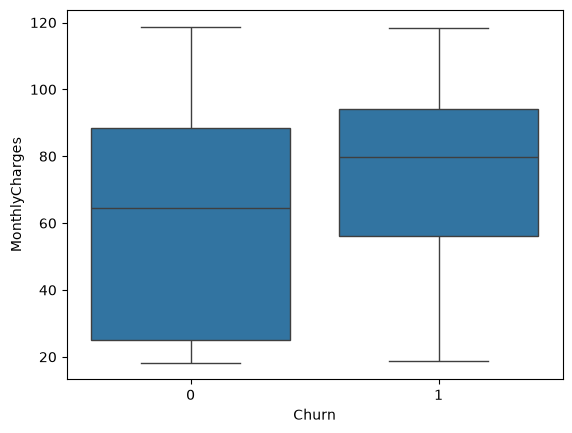

In [27]:
import seaborn as sns
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [31]:
for col in X.columns:
    try:
        pd.to_numeric(X[col])
    except ValueError as e:
        print(col, "->", e)

TotalCharges -> Unable to parse string " " at position 488


In [32]:
mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isna() & df['TotalCharges'].notna()
print(df.loc[mask, 'TotalCharges'].unique())

[' ']


In [33]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [34]:
print(df['TotalCharges'].isna().sum())

11


In [35]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [36]:
df = df.replace(r'^\s*$', pd.NA, regex=True)  # convert any whitespace-only strings to NaN
print(df.isna().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
numAdminTickets     0
numTechTickets      0
Churn               0
dtype: int64


In [38]:
print(X.dtypes[X.dtypes == 'object'])

gender              object
Partner             object
Dependents          object
PhoneService        object
MultipleLines       object
InternetService     object
OnlineSecurity      object
OnlineBackup        object
DeviceProtection    object
TechSupport         object
StreamingTV         object
StreamingMovies     object
Contract            object
PaperlessBilling    object
PaymentMethod       object
TotalCharges        object
dtype: object


In [39]:
for col in df.columns:
    print(col, df[col].dtype, df[col].unique()[:5])

gender object [0 1]
SeniorCitizen int64 [0 1]
Partner object [1 0]
Dependents object [0 1]
tenure int64 [ 1 34  2 45  8]
PhoneService object [0 1]
MultipleLines object [2 0 1]
InternetService object [1 2 0]
OnlineSecurity object [0 1 2]
OnlineBackup object [1 0 2]
DeviceProtection object [0 1 2]
TechSupport object [0 1 2]
StreamingTV object [0 1 2]
StreamingMovies object [0 1 2]
Contract object [0 1 2]
PaperlessBilling object [1 0]
PaymentMethod object [0 1 2 3]
MonthlyCharges float64 [29.85 56.95 53.85 42.3  70.7 ]
TotalCharges float64 [  29.85 1889.5   108.15 1840.75  151.65]
numAdminTickets int64 [0 1 5 2 4]
numTechTickets int64 [0 3 2 4 1]
Churn object [0 1]


In [40]:
# list the columns that SHOULD be numeric
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']  # replace with your actual numeric columns

for col in numeric_cols:
    df[col] = df[col].astype(str).str.strip()          # strip whitespace first
    df[col] = pd.to_numeric(df[col], errors='coerce')   # convert, turning junk into NaN

print(df[numeric_cols].dtypes)   # confirm they're now float64/int64
print(df[numeric_cols].isna().sum())  # check what got coerced to NaN
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


In [41]:
# list the columns that SHOULD be numeric
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']  # replace with your actual numeric columns

for col in numeric_cols:
    df[col] = df[col].astype(str).str.strip()          # strip whitespace first
    df[col] = pd.to_numeric(df[col], errors='coerce')   # convert, turning junk into NaN

print(df[numeric_cols].dtypes)   # confirm they're now float64/int64
print(df[numeric_cols].isna().sum())  # check what got coerced to NaN
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


In [42]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets
0,0,0,1,0,1,0,2,1,0,1,0,0,0,0,0,1,0,29.85,29.85,0,0
1,1,0,0,0,34,1,0,1,1,0,1,0,0,0,1,0,1,56.95,1889.5,0,0
2,1,0,0,0,2,1,0,1,1,1,0,0,0,0,0,1,1,53.85,108.15,0,0
3,1,0,0,0,45,0,2,1,1,0,1,1,0,0,1,0,2,42.30,1840.75,0,3
4,0,0,0,0,2,1,0,2,0,0,0,0,0,0,0,1,0,70.70,151.65,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,1,1,0,1,1,1,1,1,1,1,84.80,1990.5,0,0
7039,0,0,1,1,72,1,1,2,0,1,1,0,1,1,1,1,3,103.20,7362.9,0,5
7040,0,0,1,1,11,0,2,1,1,0,0,0,0,0,0,1,0,29.60,346.45,0,0
7041,1,1,1,0,4,1,1,2,0,0,0,0,0,0,0,1,1,74.40,306.6,0,0


In [43]:
for col in df.columns:
    print(col, df[col].dtype, df[col].unique()[:5])

gender object [0 1]
SeniorCitizen int64 [0 1]
Partner object [1 0]
Dependents object [0 1]
tenure int64 [ 1 34  2 45  8]
PhoneService object [0 1]
MultipleLines object [2 0 1]
InternetService object [1 2 0]
OnlineSecurity object [0 1 2]
OnlineBackup object [1 0 2]
DeviceProtection object [0 1 2]
TechSupport object [0 1 2]
StreamingTV object [0 1 2]
StreamingMovies object [0 1 2]
Contract object [0 1 2]
PaperlessBilling object [1 0]
PaymentMethod object [0 1 2 3]
MonthlyCharges float64 [29.85 56.95 53.85 42.3  70.7 ]
TotalCharges float64 [  29.85 1889.5   108.15 1840.75  151.65]
numAdminTickets int64 [0 1 5 2 4]
numTechTickets int64 [0 3 2 4 1]
Churn object [0 1]


In [45]:
categorical_cols = ['gender', 'Contract', 'PaymentMethod']  # your actual categorical columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [57]:
print(X.dtypes.value_counts()) 

object     16
int64       4
float64     1
Name: count, dtype: int64


In [47]:
X.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
numAdminTickets       int64
numTechTickets        int64
dtype: object

In [52]:
object_cols = df.select_dtypes(include='object').columns.tolist()

truly_numeric = []
categorical = []

for col in object_cols:
    converted = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce')
    if converted.notna().sum() / len(df) > 0.95:   # mostly numeric-looking
        truly_numeric.append(col)
    else:
        categorical.append(col)

print("Numeric-but-text:", truly_numeric)
print("Categorical:", categorical)

Numeric-but-text: ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']
Categorical: []


In [53]:
for col in truly_numeric:
    df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce')
    df[col] = df[col].fillna(df[col].median())

In [54]:
for col in categorical:
    n_unique = df[col].nunique()
    if n_unique == 2:
        # binary -> simple 0/1 map
        vals = df[col].dropna().unique()
        df[col] = df[col].map({vals[0]: 0, vals[1]: 1})
    else:
        # nominal with 3+ categories -> one-hot, NOT label encoding
        dummies = pd.get_dummies(df[col], prefix=col, drop_first=True).astype(int)
        df = pd.concat([df.drop(columns=[col]), dummies], axis=1)

In [55]:
print(df.dtypes.value_counts())
assert not (df.dtypes == 'object').any(), "Still have object columns!"

int64      17
bool        6
float64     2
Name: count, dtype: int64


In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
import numpy as np

# Run this on whatever variable literally goes into grid.fit(...) — X_train, not df
for col in X_train.columns:
    for i, val in enumerate(X_train[col]):
        try:
            float(val)
        except (ValueError, TypeError):
            print(f"Column: {col}, Row index: {X_train.index[i]}, Value: {repr(val)}")

In [62]:
# Force EVERYTHING to numeric, no exceptions, right before splitting
X_clean = X.copy()
for col in X_clean.columns:
    X_clean[col] = pd.to_numeric(X_clean[col], errors='coerce')

print("Remaining object columns:", X_clean.select_dtypes(include='object').columns.tolist())
print("NaNs introduced by coercion:", X_clean.isna().sum().sum())

X_clean = X_clean.fillna(X_clean.median(numeric_only=True))
assert not (X_clean.dtypes == 'object').any()

X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.25, random_state=42, stratify=y)

Remaining object columns: []
NaNs introduced by coercion: 11


In [65]:
print(y.dtype)
print(y.unique())
print(y.apply(type).value_counts())   # shows exactly which rows are str vs int/float

object
[0 1]
Churn
<class 'int'>    7043
Name: count, dtype: int64


In [74]:
X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.25, random_state=42, stratify=y)

ValueError: Found input variables with inconsistent numbers of samples: [7043, 0]

In [66]:
y = df['Churn'].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0})
print(y.isna().sum())   # check nothing fell through

7043


In [67]:
print(y.isna().sum())
y = y.dropna()
X = X.loc[y.index]   # keep X and y aligned after dropping

7043


In [68]:
print(y.value_counts(dropna=False))
print(type(y))       # should be pandas Series, not DataFrame
y = y.astype(int)     # force final dtype

Series([], Name: count, dtype: int64)
<class 'pandas.Series'>


In [71]:
print(df['Churn'].unique())
print(df['Churn'].dtype)

[0 1]
int64


In [72]:
print(y.value_counts(dropna=False))
print(len(y))   # should be 7043, not 0

Series([], Name: count, dtype: int64)
0


In [73]:
y

Series([], Name: Churn, dtype: int64)

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=42, stratify=y)

ValueError: Found input variables with inconsistent numbers of samples: [7043, 0]

In [69]:
model_grid = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=2000, class_weight='balanced'),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2']
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': [2, 5, 10]
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 150, 200],
            'max_depth': [2, 3, 4],
            'learning_rate': [0.01, 0.1, 0.2]
        }
    },
    'SVC': {
        'model': SVC(probability=True, class_weight='balanced'),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 11],
            'weights': ['uniform', 'distance']
        }
    }
}

results = []
best_estimators = {}

for name, mg in model_grid.items():
    print(f"Running GridSearchCV for {name}...")
    grid = GridSearchCV(
        estimator=mg['model'],
        param_grid=mg['params'],
        scoring='roc_auc',
        cv=5,
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train, y_train)

    test_auc = grid.score(X_test, y_test)  
    results.append({
        'Model': name,
        'Best CV AUC': grid.best_score_,
        'Test AUC': test_auc,
        'Best Params': grid.best_params_
    })
    best_estimators[name] = grid.best_estimator_

Running GridSearchCV for LogisticRegression...


ValueError: 
All the 20 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Projects\ML\Churn analysis\.env\Lib\site-packages\sklearn\model_selection\_validation.py", line 855, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Projects\ML\Churn analysis\.env\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Projects\ML\Churn analysis\.env\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1447, in fit
    check_classification_targets(y)
  File "c:\Projects\ML\Churn analysis\.env\Lib\site-packages\sklearn\utils\multiclass.py", line 230, in check_class